In [1]:
import json
import matplotlib.pyplot as plt

with open("metrics_next_word.json", "r") as f:
    datos = json.load(f)
nx_general_acc = datos["accuracy"]["general"]
nx_ambiguous_acc = datos["accuracy"]["ambiguous"]
nx_general_f1 = datos["f1_score"]["general"]
nx_ambiguous_f1 = datos["f1_score"]["ambiguous"]
nx_general_precision = datos["precision"]["general"]
nx_ambiguous_precision = datos["precision"]["ambiguous"]
nx_general_recall = datos["recall"]["general"]
nx_ambiguous_recall = datos["recall"]["ambiguous"]

with open("metrics_fill_in_the_blanks.json", "r") as f:
    datos = json.load(f)
fb_general_acc = datos["accuracy"]["general"]
fb_ambiguous_acc = datos["accuracy"]["ambiguous"]
fb_general_f1 = datos["f1_score"]["general"]
fb_ambiguous_f1 = datos["f1_score"]["ambiguous"]
fb_general_precision = datos["precision"]["general"]
fb_ambiguous_precision = datos["precision"]["ambiguous"]
fb_general_recall = datos["recall"]["general"]
fb_ambiguous_recall = datos["recall"]["ambiguous"]

In [2]:
datos

{'accuracy': {'general': [98.07405695339959,
   98.06130500274965,
   97.8237999218943,
   97.609407751592],
  'ambiguous': [97.64280282955828,
   97.67851793820134,
   97.47229198829466,
   97.26203368741216]},
 'f1_score': {'general': [85.89683208758437,
   85.89418422698415,
   85.5587451728463,
   85.33870493132115],
  'ambiguous': [84.76812696587768,
   84.7777240435529,
   84.45017032161627,
   84.05257967777172]},
 'recall': {'general': [85.95860600471497,
   85.93124151229858,
   85.63709259033203,
   85.36760807037354],
  'ambiguous': [84.80859994888306,
   84.80148315429688,
   84.51942205429077,
   84.11454558372498]},
 'precision': {'general': [85.8351469039917,
   85.85715889930725,
   85.48054099082947,
   85.3098213672638],
  'ambiguous': [84.72769260406494,
   84.75397825241089,
   84.38103199005127,
   83.99070501327515]}}

In [9]:
def plot_probing_results(num_layers, general_accuracies, ambiguous_accuracies, general_accuracies_2, ambiguous_accuracies_2, metric_string):
    layers = list(range(num_layers))
    plt.figure(figsize=(10, 6))
    plt.plot(layers, general_accuracies, marker='o', linestyle='-', linewidth=2, 
             color='blue', label=f'Fill blanks: General POS {metric_string}')
    plt.plot(layers, ambiguous_accuracies, marker='s', linestyle='--', linewidth=2, 
             color='dodgerblue', label=f'Fill blanks: Ambiguous Words POS {metric_string}')
    plt.plot(layers, general_accuracies_2, marker='o', linestyle='-', linewidth=2, 
             color='orange', label=f'Next Word: General POS {metric_string}')
    plt.plot(layers, ambiguous_accuracies_2, marker='s', linestyle='--', linewidth=2, 
             color='darkorange', label=f'Next Word: Ambiguous Words POS {metric_string}')
    all_data = general_accuracies + ambiguous_accuracies + general_accuracies_2 + ambiguous_accuracies_2
    min_val = min(all_data)
    max_val = max(all_data)
        
    plt.title('Probing Analysis: Layer-by-Layer POS Information', fontsize=14)
    plt.xlabel('Transformer Layer', fontsize=12)
    plt.ylabel(f'{metric_string}', fontsize=12)
    plt.xticks(layers)
    plt.ylim(min_val - 2, max_val + 1)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11, loc='lower right')
    plt.tight_layout()
    plt.show()

# Plot for accuracy metric

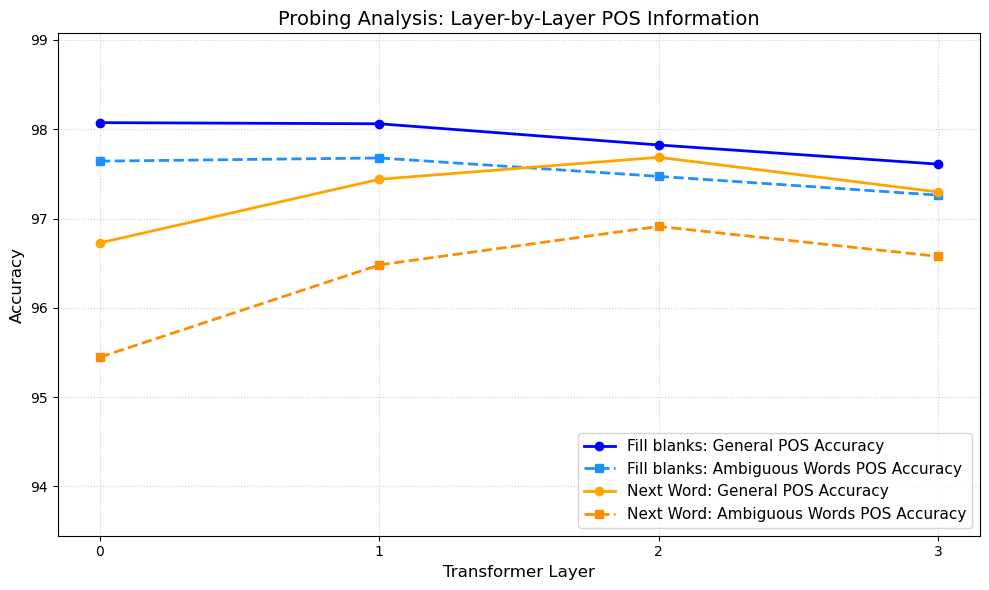

In [8]:
plot_probing_results(4, fb_general_acc, fb_ambiguous_acc, nx_general_acc, nx_ambiguous_acc, 'Accuracy')

# Plot for precision metric

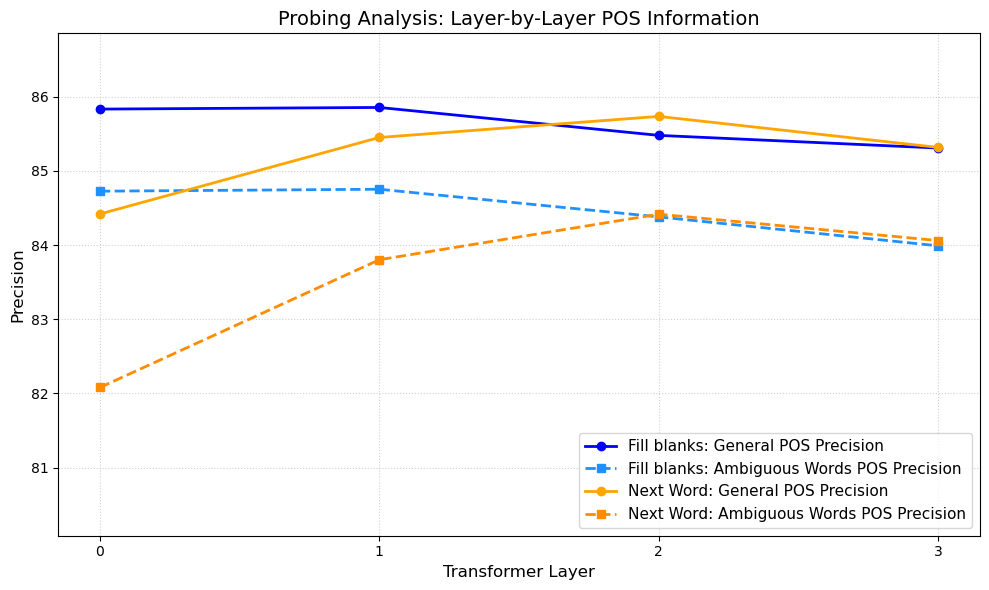

In [6]:
plot_probing_results(4, fb_general_precision, fb_ambiguous_precision, nx_general_precision, nx_ambiguous_precision, 'Precision')

# Plot for recall metric

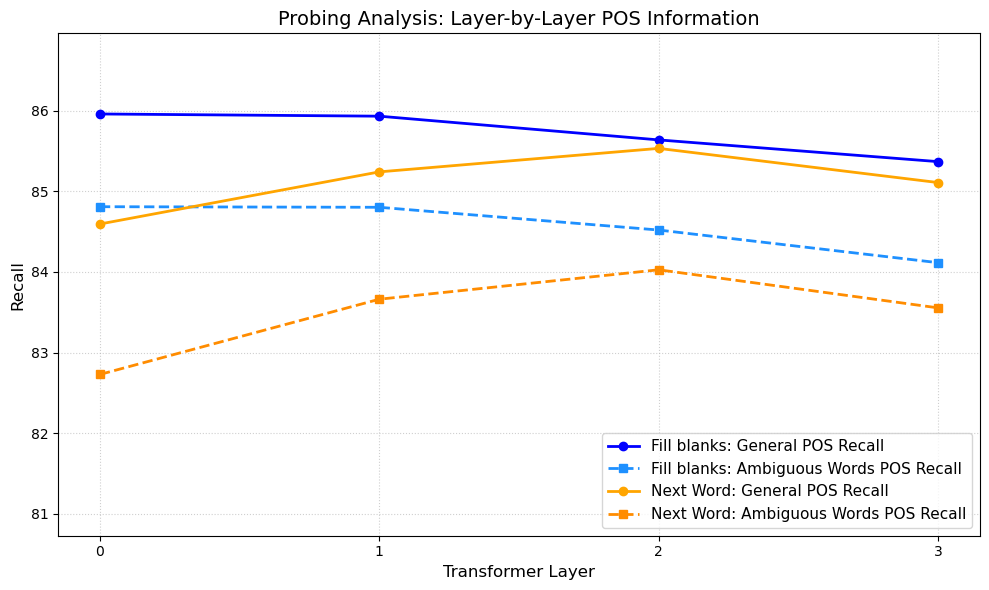

In [7]:
plot_probing_results(4, fb_general_recall, fb_ambiguous_recall, nx_general_recall, nx_ambiguous_recall, 'Recall')

# Plot for F1 metric

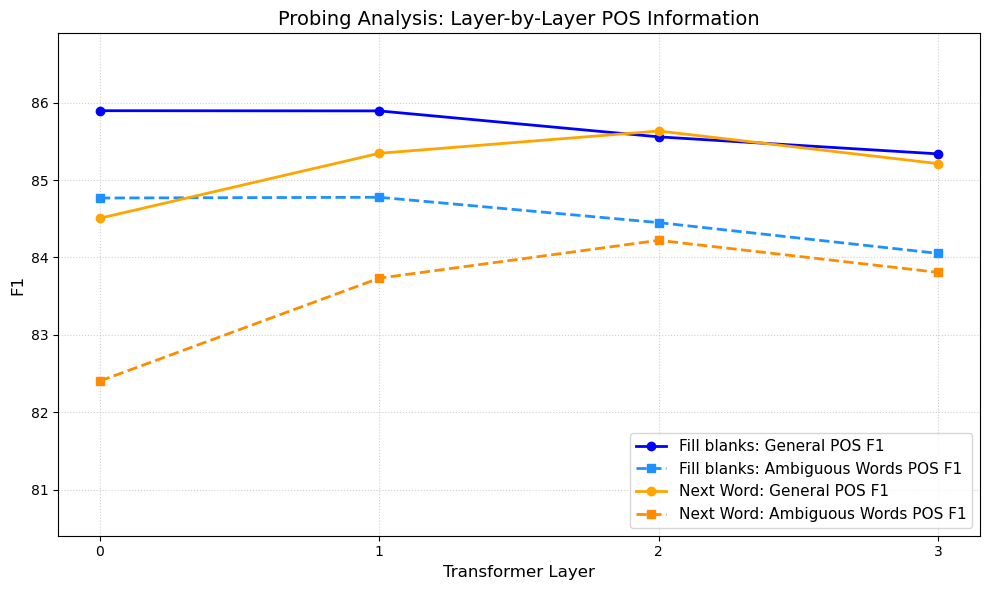

In [5]:
plot_probing_results(4, fb_general_f1, fb_ambiguous_f1, nx_general_f1, nx_ambiguous_f1, 'F1')